<a href="https://colab.research.google.com/github/mszhdgr/Machine_learning/blob/Main/Linear%20Regression/checkmates.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## KNN Regressor Model

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harshadapatil31/student-performance-and-study-habits-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-performance-and-study-habits-dataset' dataset.
Path to dataset files: /kaggle/input/student-performance-and-study-habits-dataset


In [8]:
import pandas as pd

df = pd.read_csv("/kaggle/input/student-performance-and-study-habits-dataset/student_performance_dataset.csv")
df.head(5)

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [9]:
df.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


In [11]:
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 898 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  898 non-null    int64  
 1   gender                      898 non-null    object 
 2   study_time_hours            898 non-null    float64
 3   attendance_percent          898 non-null    float64
 4   sleep_hours                 898 non-null    float64
 5   parental_education          898 non-null    object 
 6   internet_access             898 non-null    object 
 7   extracurricular_activities  898 non-null    object 
 8   part_time_job               898 non-null    object 
 9   previous_grade              898 non-null    float64
 10  final_exam_score            898 non-null    float64
 11  final_grade                 898 non-null    object 
dtypes: float64(5), int64(1), object(6)
memory usage: 91.2+ KB


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
len(df)

898

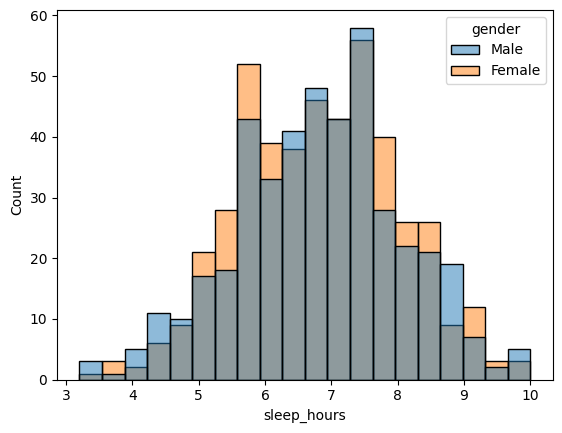

In [30]:
sns.histplot(x='sleep_hours', hue='gender', data=df)
plt.show()

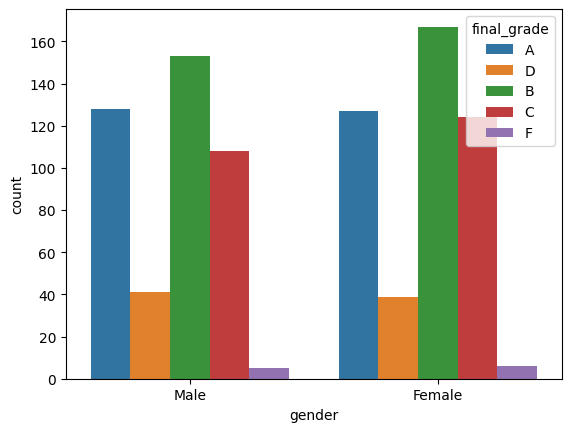

In [32]:
sns.countplot(x='gender', hue='final_grade', data=df)
plt.show()

In [38]:
int_cols = ['study_time_hours',	'attendance_percent',	'sleep_hours','previous_grade','final_exam_score']
new_df = pd.DataFrame(df, columns=int_cols)
new_df.head(5)

,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
0,4.0,98.0,6.5,76.9,100.0
1,6.3,100.0,5.7,75.5,100.0
2,4.9,85.3,7.9,88.5,97.3
4,2.2,89.6,4.6,61.8,68.3
5,4.2,78.2,5.7,79.8,81.6


In [39]:
corr = new_df.corr()

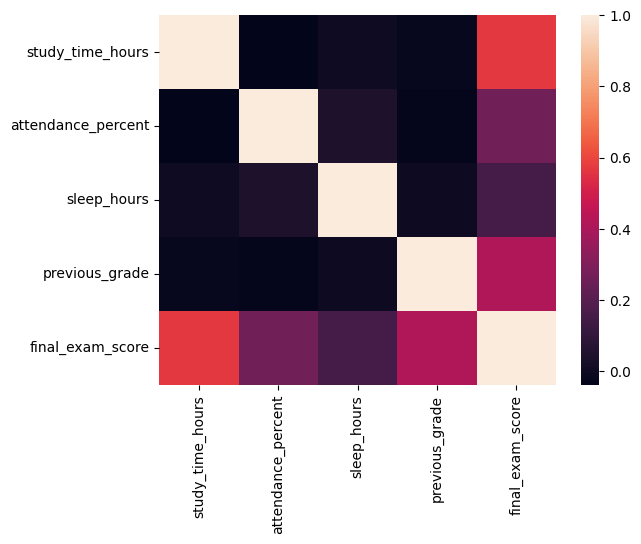

In [40]:
sns.heatmap(corr)
plt.show()

In [51]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=3)

In [46]:
x = new_df.drop(columns=['final_exam_score'])
x.head(5)

,study_time_hours,attendance_percent,sleep_hours,previous_grade
0,4.0,98.0,6.5,76.9
1,6.3,100.0,5.7,75.5
2,4.9,85.3,7.9,88.5
4,2.2,89.6,4.6,61.8
5,4.2,78.2,5.7,79.8


In [47]:
y = new_df['final_exam_score'].values
y[:5]

array([100. , 100. ,  97.3,  68.3,  81.6])

In [52]:
knn.fit(x, y)

KNeighborsRegressor(n_neighbors=3)

In [60]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")

neto = np.array([6.0, 70.0, 8.0, 79.0])
pred = knn.predict(neto.reshape(1, -1))

In [61]:
pred

array([85.66666667])

## Binary

In [62]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("iammustafatz/diabetes-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'diabetes-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/diabetes-prediction-dataset


In [63]:
df = pd.read_csv("/kaggle/input/diabetes-prediction-dataset/diabetes_prediction_dataset.csv")
df.head(5)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [64]:
num_cols = df.drop(columns=['gender','smoking_history','diabetes'])
num_cols.head(5)

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level
0,80.0,0,1,25.19,6.6,140
1,54.0,0,0,27.32,6.6,80
2,28.0,0,0,27.32,5.7,158
3,36.0,0,0,23.45,5.0,155
4,76.0,1,1,20.14,4.8,155


In [65]:
labels = df['diabetes'].values
labels[:5]

array([0, 0, 0, 0, 0])

In [73]:
y = labels.reshape(-1, 1)
y[:3]

array([[0],
       [0],
       [0]])

In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(num_cols)

In [68]:
x_scaled

array([[ 1.69270354e+00, -2.84439447e-01,  4.93637859e+00,
        -3.21055792e-01,  1.00170572e+00,  4.77042159e-02],
       [ 5.38006427e-01, -2.84439447e-01, -2.02577655e-01,
        -1.15583678e-04,  1.00170572e+00, -1.42620999e+00],
       [-6.16690686e-01, -2.84439447e-01, -2.02577655e-01,
        -1.15583678e-04,  1.61108022e-01,  4.89878478e-01],
       ...,
       [ 1.07094356e+00, -2.84439447e-01, -2.02577655e-01,
         7.67292549e-02,  1.61108022e-01,  4.16182767e-01],
       [-7.94336396e-01, -2.84439447e-01, -2.02577655e-01,
         1.22036126e+00, -1.42668764e+00, -9.34905254e-01],
       [ 6.71240710e-01, -2.84439447e-01, -2.02577655e-01,
        -7.36921977e-01,  1.00170572e+00, -1.18055762e+00]])

In [74]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(x_scaled, y)

LogisticRegression()

In [77]:
wafula = np.array([30, 0, 0, 24.0, 5.0, 70]).reshape(1, -1)
pred = lr.predict(wafula)
pred

array([1])